# ДЗ №1 СУНЦ МГУ - Numpy practice

**Среда:** Python 3.14.7. Локальные модули `functions.py` и `functions_vectorized.py` повторно импортируются при каждом запуске ячейки с решением.


### Туториальные задачи
__(9 баллов)__

Ниже приведены задачи на работу с numpy-массивами. Для каждой из задач нужно привести 2 реализации: одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная (без использования питоновских циклов/map/list comprehension). Невекторизованная реализация каждой из задач оценивается в __0.5 балла__, векторизованная – в __1 балл__.

Реализации без использования векторизации нужно записать в файл functions.py, а векторизованные &mdash; в файл functions_vectorized.py

Для каждой задачи, приведённой ниже сравните скорость работы невекторизованной и векторизованной реализации. С помощью пакета matplotlib постройте графики времени работы в зависимости от размера данных. __Графики должны выглядеть опрятно!__ То есть должны быть подписаны оси, названия графиков, и т.д. Например, ниже представлены хороший и плохой графики:

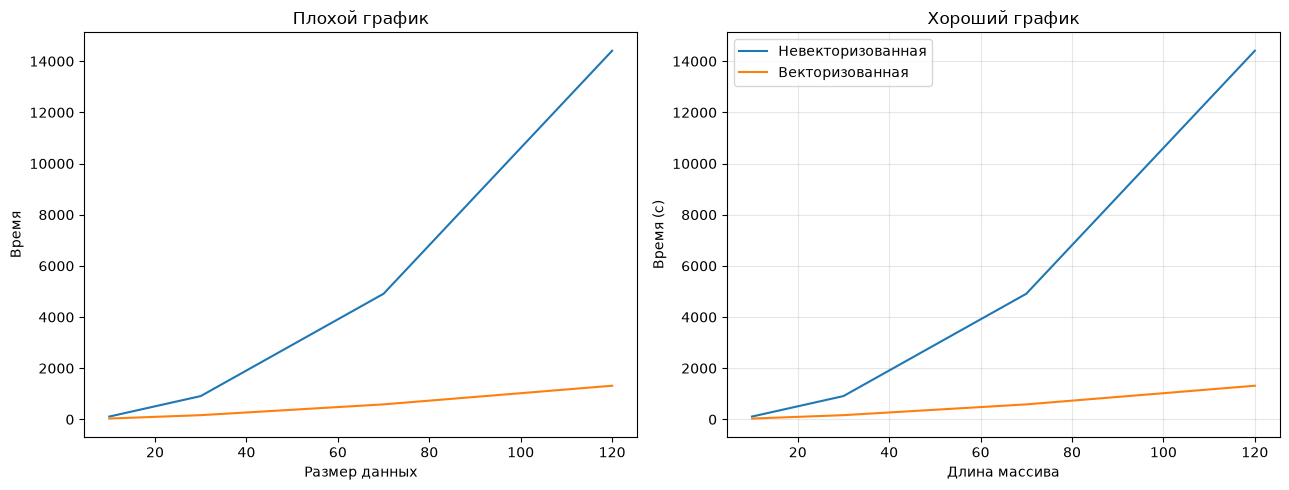

In [70]:
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np

import functions
import functions_vectorized

%matplotlib inline


def reload_solution_modules():
    """Reload the two local solution modules after their files change."""
    reload(functions)
    reload(functions_vectorized)


data_size = np.array([10, 30, 70, 120])
time_non_vectorized = data_size**2 + 10
time_vectorized = data_size**1.5

figure, (axis_bad, axis_good) = plt.subplots(1, 2, figsize=(13, 5))

axis_bad.plot(data_size, time_non_vectorized)
axis_bad.plot(data_size, time_vectorized)
axis_bad.set_title("Плохой график")
axis_bad.set_xlabel("Размер данных")
axis_bad.set_ylabel("Время")

axis_good.plot(data_size, time_non_vectorized, label="Невекторизованная")
axis_good.plot(data_size, time_vectorized, label="Векторизованная")
axis_good.set_title("Хороший график")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()


* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ – 3.

невект.: 3
вект.:   3


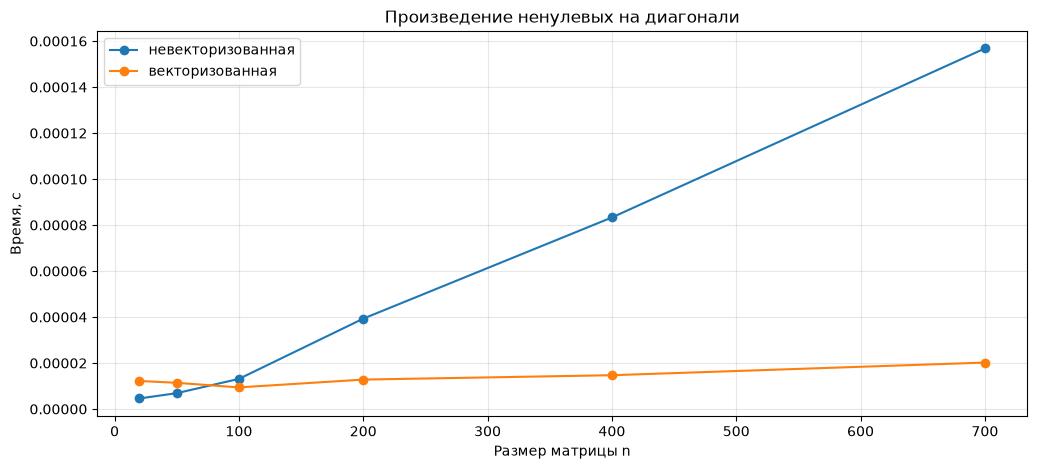

In [71]:
reload_solution_modules()

import time

x = [[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]
print("невект.:", functions.prod_non_zero_diag(x))
print("вект.:  ", functions_vectorized.prod_non_zero_diag(np.array(x)))

def tm(func, *args, repeats = 3):
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter()
        func(*args)
        t1 = time.perf_counter()
        best = min(best, t1 - t0)
    return best

rng = np.random.default_rng(0) #чоб одинаковые были
sz = [20, 50, 100, 200, 400, 700]
yn, yv = [], []
for n in sz:
    lst = rng.integers(0, 5, size=(n, n + 30))
    yn.append(tm(functions.prod_non_zero_diag, lst.tolist()))
    yv.append(tm(functions_vectorized.prod_non_zero_diag, lst))

plt.figure(figsize=(12, 5))
plt.plot(sz, yn, 'o-', label='невекторизованная')
plt.plot(sz, yv, 'o-', label='векторизованная')
plt.xlabel('Размер матрицы n')
plt.ylabel('Время, с')
plt.title('Произведение ненулевых на диагонали') ##
plt.grid(True, alpha=0.3)
plt.legend()
plt.show() ##

 
 
* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ – True.
  
  


невект.: True
вект.:   True


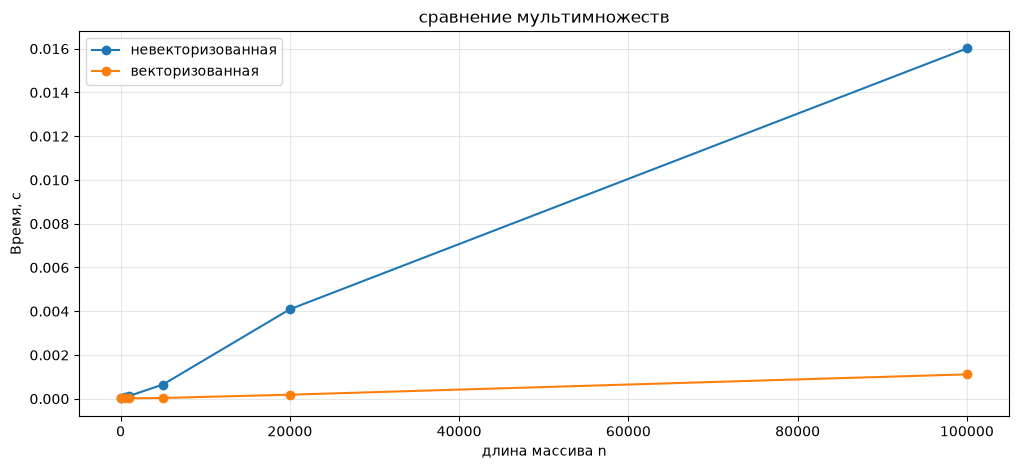

In [72]:
reload_solution_modules()

import time

x = [1, 2, 2, 4]
y = [4, 2, 1, 2]

print("невект.:", functions.are_multisets_equal(x, y))
print("вект.:  ", functions_vectorized.are_multisets_equal(np.array(x), np.array(y)))

def tm(func, *args, repeats = 3):
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter()
        func(*args)
        t1 = time.perf_counter()
        best = min(best, t1 - t0)
    return best

rng = np.random.default_rng(0) #чоб одинаковые были
sz = [100, 500, 1000, 5000, 20000, 100000]
yn, yv = [], []
for n in sz:
    xt = rng.integers(0, 5, size = (n))
    yt = xt.copy()
    rng.shuffle(yt)
    yn.append(tm(functions.are_multisets_equal, xt.tolist(), yt.tolist()))
    yv.append(tm(functions_vectorized.are_multisets_equal, xt, yt))

plt.figure(figsize = (12, 5))
plt.plot(sz, yn, 'o-', label = 'невекторизованная')
plt.plot(sz, yv, 'o-', label = 'векторизованная')
plt.xlabel('длина массива n')
plt.ylabel('Время, с')
plt.title('сравнение мультимножеств') ##
plt.grid(True, alpha=0.3)
plt.legend()
plt.show() ##

* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой.  
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ – 5.

невект.: 5
вект.:   5


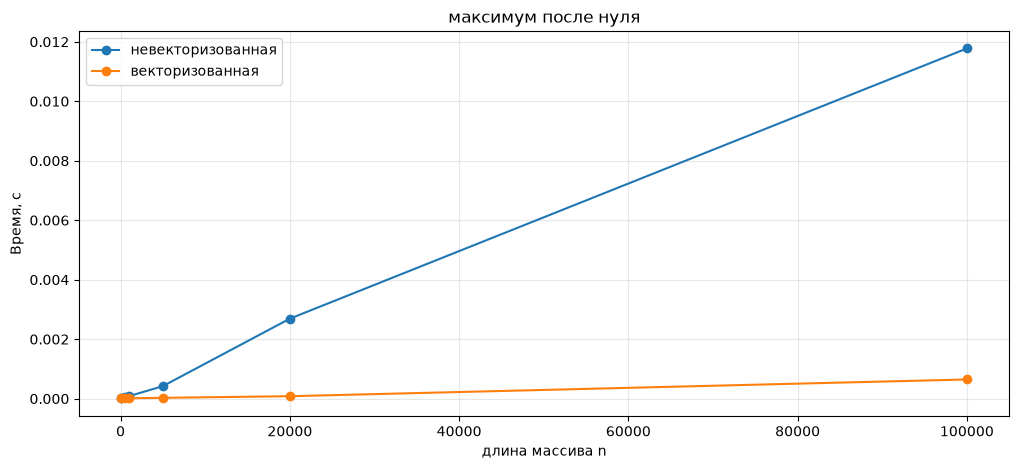

In [73]:
reload_solution_modules()

import time

x = [6, 2, 0, 3, 0, 0, 5, 7, 0]

print("невект.:", functions.max_after_zero(x))
print("вект.:  ", functions_vectorized.max_after_zero(np.array(x)))

def tm(func, *args, repeats = 3):
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter()
        func(*args)
        t1 = time.perf_counter()
        best = min(best, t1 - t0)
    return best

rng = np.random.default_rng(0) #чоб одинаковые были
sz = [100, 500, 1000, 5000, 20000, 100000]
yn, yv = [], []
for n in sz:
    xt = rng.integers(0, 5, size = (n))
    yn.append(tm(functions.max_after_zero, xt.tolist()))
    yv.append(tm(functions_vectorized.max_after_zero, xt))

plt.figure(figsize = (12, 5))
plt.plot(sz, yn, 'o-', label = 'невекторизованная')
plt.plot(sz, yv, 'o-', label = 'векторизованная')
plt.xlabel('длина массива n')
plt.ylabel('Время, с')
plt.title('максимум после нуля') ##
plt.grid(True, alpha=0.3)
plt.legend()
plt.show() ##

 
 
* __Задача 4__: Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). В ноутбуке приведите пример работы функции – преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]). Считать реальное изображение можно с помощью `PIL.Image.open` из пакета Pillow: `img = np.asarray(Image.open(path).convert("RGB"))`. Устаревшая функция `scipy.misc.imread` удалена из современных версий SciPy.


невект.: [[140.75, 18.15], [255.0, 0.0]]
вект.:   [[140.75  18.15]
 [255.     0.  ]]


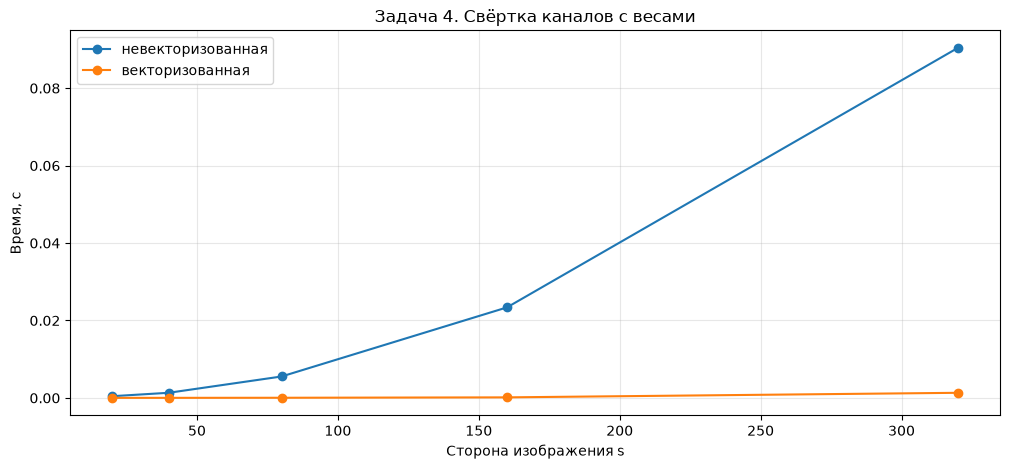

In [74]:
reload_solution_modules()

import time

cf = np.array([0.299, 0.587, 0.114])

img_ex = np.array([
    [[100, 150, 200], [10, 20, 30]],
    [[255, 255, 255], [0, 0, 0]],
], dtype=np.uint8)

print("невект.:", functions.mix_channels(img_ex.tolist(), cf.tolist()))
print("вект.:  ", functions_vectorized.mix_channels(img_ex, cf))

def tm(func, *args, repeats = 3):
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter()
        func(*args)
        t1 = time.perf_counter()
        best = min(best, t1 - t0)
    return best

rng = np.random.default_rng(0)
sz = [20, 40, 80, 160, 320]
yn, yv = [], []
for s in sz:
    img = rng.integers(0, 256, size = (s, s, 3), dtype = np.uint8)
    yn.append(tm(functions.mix_channels, img.tolist(), cf.tolist()))
    yv.append(tm(functions_vectorized.mix_channels, img, cf))

plt.figure(figsize = (12, 5))
plt.plot(sz, yn, 'o-', label = 'невекторизованная')
plt.plot(sz, yv, 'o-', label = 'векторизованная')
plt.xlabel('Сторона изображения s')
plt.ylabel('Время, с')
plt.title('Задача 4. Свёртка каналов с весами')
plt.grid(True, alpha = 0.3)
plt.legend()
plt.show()

* __Задача 5__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ – (np.array([2, 3, 5]), np.array([3, 3, 1])).

невект.: ([2, 3, 5], [3, 3, 1])
вект.:   (array([2, 3, 5]), array([3, 3, 1]))


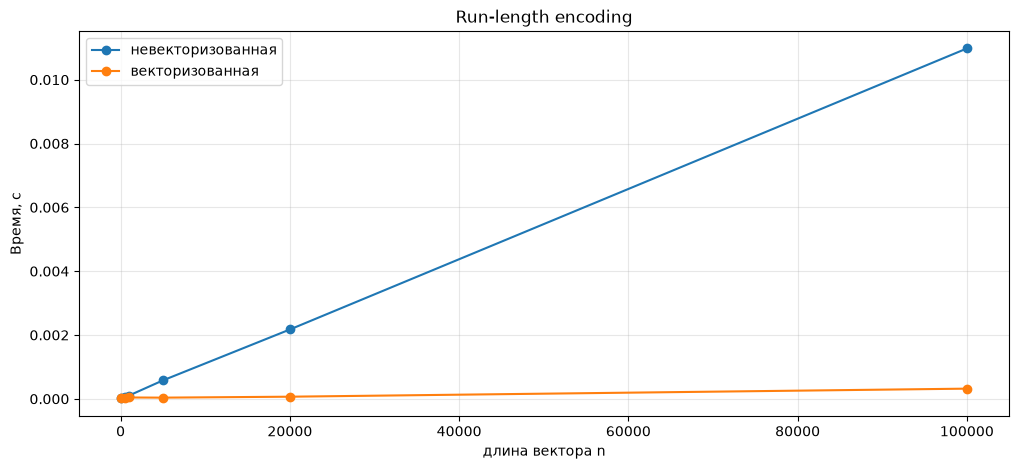

In [75]:
reload_solution_modules()

import time

x0 = [2, 2, 2, 3, 3, 3, 5]

print("невект.:", functions.run_length_encoding(x0))
print("вект.:  ", functions_vectorized.run_length_encoding(np.array(x0)))

def tm(func, *args, repeats = 3):
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter()
        func(*args)
        t1 = time.perf_counter()
        best = min(best, t1 - t0)
    return best

rng = np.random.default_rng(0)
sz = [100, 500, 1000, 5000, 20000, 100000]
yn, yv = [], []
for n in sz:
    a = np.repeat(rng.integers(0, 50, size = n // 10 + 1), 10)[:n]
    yn.append(tm(functions.run_length_encoding, a.tolist()))
    yv.append(tm(functions_vectorized.run_length_encoding, a))

plt.figure(figsize=(12, 5))
plt.plot(sz, yn, 'o-', label='невекторизованная')
plt.plot(sz, yv, 'o-', label='векторизованная')
plt.xlabel('длина вектора n')
plt.ylabel('Время, с')
plt.title('Run-length encoding')
plt.grid(True, alpha = 0.3)
plt.legend()
plt.show()

 
 
* __Задача 6__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Дополнительно сравните с функцией scipy.spatial.distance.cdist по скорости работы (сравнения приведите ниже в ноутбуке).

невект.:
[[0.         1.        ]
 [5.         4.47213595]]
вект.:
[[0.         1.        ]
 [5.         4.47213595]]


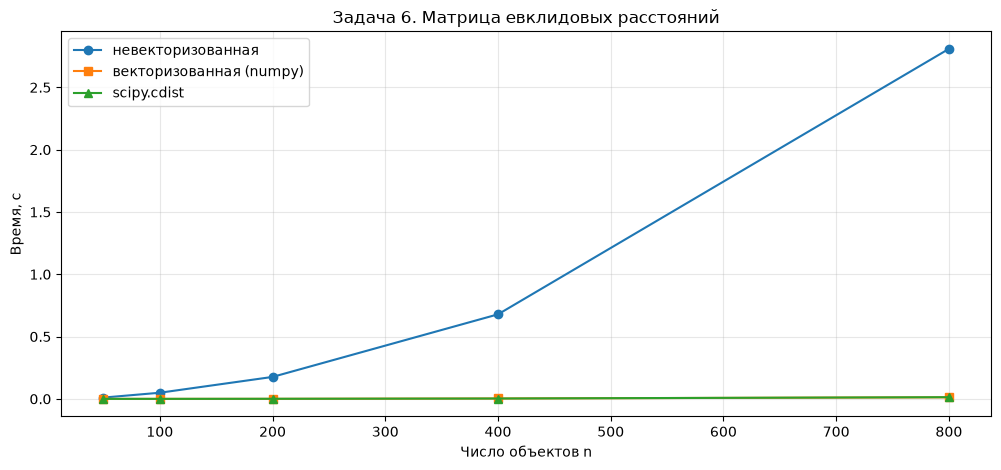

In [93]:
reload_solution_modules()

import time
from scipy.spatial.distance import cdist

X0 = [[0, 0], [3, 4]]
Y0 = [[0, 0], [1, 0]]
print("невект.:")
print(np.array(functions.pairwise_distance(X0, Y0)))
print("вект.:")
print(functions_vectorized.pairwise_distance(np.array(X0), np.array(Y0)))

def tm(func, *args, repeats=3):
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter()
        func(*args)
        t1 = time.perf_counter()
        best = min(best, t1 - t0)
    return best

rng = np.random.default_rng(0)
sz = [50, 100, 200, 400, 800]
d = 20
yn, yv, ys = [], [], []
for n in sz:
    X = rng.normal(size=(n, d))
    Y = rng.normal(size=(n, d))
    yn.append(tm(functions.pairwise_distance, X.tolist(), Y.tolist()))
    yv.append(tm(functions_vectorized.pairwise_distance, X, Y))
    ys.append(tm(cdist, X, Y))

plt.figure(figsize=(12, 5))
plt.plot(sz, yn, 'o-', label='невекторизованная')
plt.plot(sz, yv, 's-', label='векторизованная (numpy)')
plt.plot(sz, ys, '^-', label='scipy.cdist')
plt.xlabel('Число объектов n')
plt.ylabel('Время, с')
plt.title('Задача 6. Матрица евклидовых расстояний')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Туториал по Markdown

__(1 балл)__

Напишите краткий (а в данной домашке ещё и почти бесмысленный) отчёт с использованием 4-5 различных вариантов разметки/выделения текста.

# дз №1 numpy

## что сделала

для **5 задач** написала *две* версии:
1. обычную, невекторизованную
2. векторизованную

> numpy на больших данных намного быстрее


| задача | обычно | numpy |
|--------|--------|-------|
| 1      | for   | `np.diagonal` |
| 2      | `sorted` | `np.sort` |

_класс._